<a href="https://colab.research.google.com/github/Harsh-Sama/MANIT-Submissions/blob/main/PracticalExamCode_Sem2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 7, 7, 16)       │         4,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 28, 28, 1)      │         7,249 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,193 (47.63 KB)

 Trainable params: 12,193 (47.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 110s 230ms/step - loss: 0.3092 - val_loss: 0.2809
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 108s 229ms/step - loss: 0.2755 - val_loss: 0.2750
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 109s 232ms/step - loss: 0.2711 - val_loss: 0.2716
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 145s 239ms/step - loss: 0.2685 - val_loss: 0.2699
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 143s 242ms/step - loss: 0.2664 - val_loss: 0.2676
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step


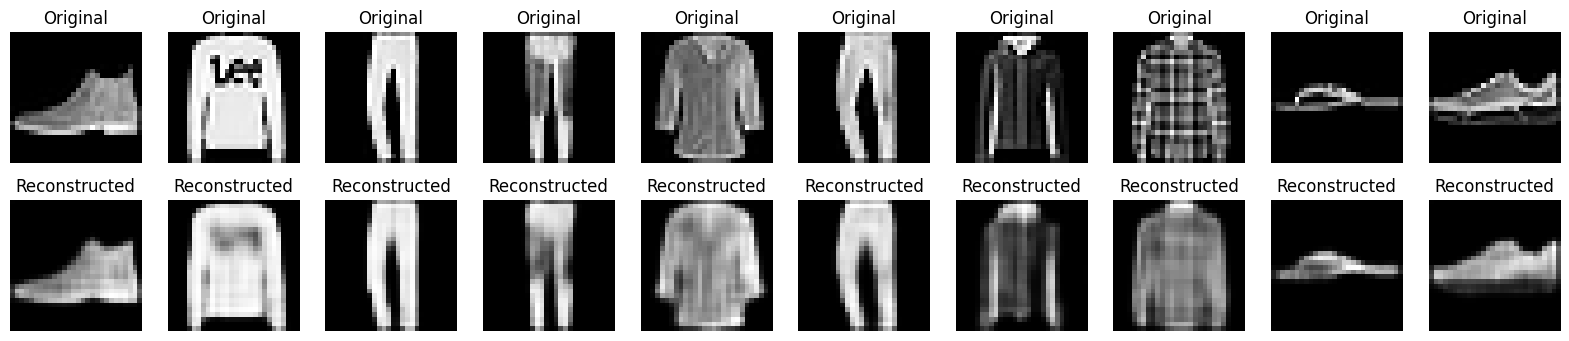

In [1]:
# Import required libraries
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

# Load Fashion MNIST dataset
(x_train, _), (x_test, _) = tf.keras.datasets.fashion_mnist.load_data()

# Normalize pixel values (0 to 1)
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reshape for neural network (add channel dimension)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# -------------------------------
# Build Autoencoder Model
# -------------------------------

# Encoder
encoder = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2), padding='same'),
    layers.Conv2D(16, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2), padding='same')
])

# Decoder
decoder = models.Sequential([
    layers.Conv2D(16, (3,3), activation='relu', padding='same'),
    layers.UpSampling2D((2,2)),
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.UpSampling2D((2,2)),
    layers.Conv2D(1, (3,3), activation='sigmoid', padding='same')
])

# Combine encoder and decoder
autoencoder = models.Sequential([encoder, decoder])

# Compile model
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# Model summary (optional for viva)
autoencoder.summary()

# -------------------------------
# Train the model
# -------------------------------
history = autoencoder.fit(
    x_train, x_train,   # input = output (autoencoder)
    epochs=5,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test, x_test)
)

# -------------------------------
# Test & visualize results
# -------------------------------

# Predict reconstructed images
decoded_imgs = autoencoder.predict(x_test)

# Display original vs reconstructed images
n = 10
plt.figure(figsize=(20, 4))

for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis("off")

    # Reconstructed
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.title("Reconstructed")
    plt.axis("off")

plt.show()